# Backtest and Results Notebook  
## Aave-хеджированная LP-стратегия ETH/USDC

Этот ноутбук воспроизводит финальный historical backtest проекта и собирает основные результаты для whitepaper и презентации.

Основная стратегия:

```text
Uniswap V2 ETH/USDC LP + Aave-style WETH debt hedge
```

Финальный backtest использует:

```text
fractal-defi для AMM LP mechanics
project strategy layer для Aave hedge accounting, rebalance, costs и risk controls
```

Калиброванные параметры:

```text
hedge_ratio = 0.8499892802109696
rebalance_threshold = 0.06965934324744885
slippage_bps = 10
gas_cost_usdc = 15
```

## 1. Notebook setup

In [20]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()

# If this notebook is opened from research/notebooks, move two levels up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "research":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("PROJECT_ROOT:", PROJECT_ROOT)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "market_data.csv"

BASE_RESULTS_DIR = PROJECT_ROOT / "reports" / "results_tables"
CALIBRATED_RESULTS_DIR = PROJECT_ROOT / "reports" / "results_tables" / "fractal_calibrated"
CALIBRATION_DIR = PROJECT_ROOT / "reports" / "results_tables" / "calibration"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
CALIBRATED_FIGURES_DIR = FIGURES_DIR / "fractal_calibrated"

for path in [BASE_RESULTS_DIR, CALIBRATED_RESULTS_DIR, FIGURES_DIR, CALIBRATED_FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"

PROJECT_ROOT: d:\VS\defi-lp-aave-hedge-strategy


## 2. Backtest parameters

Эти параметры соответствуют финальной calibrated specification.  
Они были найдены через Optuna calibration по двум strategy-control параметрам:

```text
hedge_ratio
rebalance_threshold
```

Execution/risk-policy параметры не оптимизировались.

In [21]:
HEDGE_RATIO = 0.8499892802109696
REBALANCE_THRESHOLD = 0.06965934324744885
SLIPPAGE_BPS = 10.0
GAS_COST_USDC = 15.0
INITIAL_CAPITAL_USDC = 100_000.0

PARAMS = {
    "hedge_ratio": HEDGE_RATIO,
    "rebalance_threshold": REBALANCE_THRESHOLD,
    "slippage_bps": SLIPPAGE_BPS,
    "gas_cost_usdc": GAS_COST_USDC,
    "initial_capital_usdc": INITIAL_CAPITAL_USDC,
}

PARAMS

{'hedge_ratio': 0.8499892802109696,
 'rebalance_threshold': 0.06965934324744885,
 'slippage_bps': 10.0,
 'gas_cost_usdc': 15.0,
 'initial_capital_usdc': 100000.0}

## 3. Optional: run calibrated fractal backtest

Ячейка ниже перезапускает финальный calibrated backtest и сохраняет результаты в:

```text
reports/results_tables/fractal_calibrated/
```

Если результаты уже есть, можно не запускать эту ячейку.

In [22]:
RUN_BACKTEST = False

if RUN_BACKTEST:
    cmd = [
        sys.executable,
        "-m",
        "strategy.fractal_runner",
        "--data-path",
        str(DATA_PATH),
        "--output-dir",
        str(CALIBRATED_RESULTS_DIR),
        "--hedge-ratio",
        str(HEDGE_RATIO),
        "--rebalance-threshold",
        str(REBALANCE_THRESHOLD),
        "--slippage-bps",
        str(SLIPPAGE_BPS),
        "--gas-cost-usdc",
        str(GAS_COST_USDC),
    ]

    print("Running command:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
        check=True,
    )

    print(result.stdout)
else:
    print("Skipped. Set RUN_BACKTEST = True to rerun calibrated fractal backtest.")

Skipped. Set RUN_BACKTEST = True to rerun calibrated fractal backtest.


## 4. Load market data and backtest outputs

In [23]:
market = pd.read_csv(DATA_PATH)
market["timestamp"] = pd.to_datetime(market["timestamp"], utc=True)
market = market.sort_values("timestamp").reset_index(drop=True)

metrics_path = CALIBRATED_RESULTS_DIR / "metrics.csv"
nav_path = CALIBRATED_RESULTS_DIR / "nav_timeseries.csv"
rebalances_path = CALIBRATED_RESULTS_DIR / "rebalances.csv"
pnl_path = CALIBRATED_RESULTS_DIR / "pnl_decomposition.csv"

assert metrics_path.exists(), f"Missing metrics: {metrics_path}"
assert nav_path.exists(), f"Missing nav_timeseries: {nav_path}"

metrics = pd.read_csv(metrics_path)
nav = pd.read_csv(nav_path, low_memory=False)
nav["timestamp"] = pd.to_datetime(nav["timestamp"], utc=True)

rebalances = pd.read_csv(rebalances_path) if rebalances_path.exists() else pd.DataFrame()
if not rebalances.empty and "timestamp" in rebalances.columns:
    rebalances["timestamp"] = pd.to_datetime(rebalances["timestamp"], utc=True)

pnl = pd.read_csv(pnl_path) if pnl_path.exists() else pd.DataFrame()

print("market:", market.shape, market["timestamp"].min(), "→", market["timestamp"].max())
print("metrics:", metrics.shape)
print("nav:", nav.shape)
print("rebalances:", rebalances.shape)
print("pnl:", pnl.shape)

market: (8737, 10) 2025-01-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00
metrics: (4, 12)
nav: (34948, 28)
rebalances: (13, 11)
pnl: (4, 10)


## 5. Metrics table

Основные стратегии:

```text
buy_hold_50_50
fractal_plain_uniswap_v2_lp
fractal_fixed_hedge_lp
fractal_dynamic_aave_hedged_lp
```

In [24]:
def format_metrics_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    percent_cols = ["annualized_return", "annualized_volatility", "max_drawdown", "average_idle_ratio"]
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].astype(float) * 100

    rename = {
        "strategy_name": "Strategy",
        "final_nav": "Final NAV",
        "net_pnl": "Net PnL",
        "annualized_return": "Ann. Return, %",
        "annualized_volatility": "Ann. Volatility, %",
        "sharpe": "Sharpe",
        "max_drawdown": "Max DD, %",
        "turnover": "Turnover",
        "number_of_rebalances": "Rebalances",
        "total_costs": "Total Costs",
        "average_health_factor": "Avg. Health Factor",
        "average_idle_ratio": "Avg. Idle Ratio, %",
    }

    out = out.rename(columns=rename)

    order = [
        "Strategy", "Final NAV", "Net PnL", "Ann. Return, %",
        "Ann. Volatility, %", "Sharpe", "Max DD, %",
        "Turnover", "Rebalances", "Total Costs",
        "Avg. Health Factor", "Avg. Idle Ratio, %",
    ]

    out = out[[c for c in order if c in out.columns]]

    return out

formatted_metrics = format_metrics_table(metrics)
formatted_metrics

,Strategy,Final NAV,Net PnL,"Ann. Return, %","Ann. Volatility, %",Sharpe,"Max DD, %",Turnover,Rebalances,Total Costs,Avg. Health Factor,"Avg. Idle Ratio, %"
0,buy_hold_50_50,94137.823186,-5862.176814,-5.877799,33.350779,-0.014714,-32.483243,0.000000,0,0.000000,inf,0.000000
1,fractal_dynamic_aave_hedged_lp,103761.011221,3836.011221,3.849637,6.280751,0.632765,-2.044274,22182.966296,13,217.182966,1.969673,21.362823
2,fractal_fixed_hedge_lp,106031.858214,6106.858214,6.128736,6.964330,0.888842,-4.129022,0.000000,0,0.000000,2.297686,20.285612
3,fractal_plain_uniswap_v2_lp,104405.331848,4555.331848,4.574991,36.171984,0.304975,-35.697318,0.000000,0,0.000000,inf,0.000000


In [25]:
# Save formatted metrics for whitepaper/presentation.
formatted_metrics.to_csv(CALIBRATED_RESULTS_DIR / "metrics_formatted_for_presentation.csv", index=False)
print("Saved:", CALIBRATED_RESULTS_DIR / "metrics_formatted_for_presentation.csv")

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\metrics_formatted_for_presentation.csv


### Ключевая интерпретация метрик

В этой версии стратегия интерпретируется не как return-maximizing стратегия, а как risk-management стратегия.

Главное сравнение:

```text
Plain LP:
    higher absolute return than buy & hold, but very high drawdown

Fixed Hedge LP:
    strong baseline, good final NAV and Sharpe

Calibrated Dynamic Hedge:
    best downside protection, lowest max drawdown, but not highest final NAV
```

In [26]:
def get_metric(strategy: str, col: str) -> float:
    row = metrics.loc[metrics["strategy_name"] == strategy]
    if row.empty:
        return float("nan")
    return float(row[col].iloc[0])

plain_dd = get_metric("fractal_plain_uniswap_v2_lp", "max_drawdown")
dyn_dd = get_metric("fractal_dynamic_aave_hedged_lp", "max_drawdown")
plain_vol = get_metric("fractal_plain_uniswap_v2_lp", "annualized_volatility")
dyn_vol = get_metric("fractal_dynamic_aave_hedged_lp", "annualized_volatility")
dyn_sharpe = get_metric("fractal_dynamic_aave_hedged_lp", "sharpe")
fixed_sharpe = get_metric("fractal_fixed_hedge_lp", "sharpe")

summary_text = (
    f"Plain LP max drawdown: {plain_dd:.2%}\n"
    f"Calibrated dynamic hedge max drawdown: {dyn_dd:.2%}\n\n"
    f"Plain LP annualized volatility: {plain_vol:.2%}\n"
    f"Calibrated dynamic hedge annualized volatility: {dyn_vol:.2%}\n\n"
    f"Calibrated dynamic hedge Sharpe: {dyn_sharpe:.2f}\n"
    f"Fixed hedge Sharpe: {fixed_sharpe:.2f}\n\n"
    "Interpretation:\n"
    "Aave hedge significantly improves downside protection versus plain LP.\n"
    "However, fixed hedge remains a strong baseline and has higher Sharpe/final NAV in this historical sample."
)

print(summary_text)

Plain LP max drawdown: -35.70%
Calibrated dynamic hedge max drawdown: -2.04%

Plain LP annualized volatility: 36.17%
Calibrated dynamic hedge annualized volatility: 6.28%

Calibrated dynamic hedge Sharpe: 0.63
Fixed hedge Sharpe: 0.89

Interpretation:
Aave hedge significantly improves downside protection versus plain LP.
However, fixed hedge remains a strong baseline and has higher Sharpe/final NAV in this historical sample.


## 6. Equity curve

График показывает динамику NAV стратегий во времени.  
Для презентации это один из основных графиков.

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\fractal_calibrated\calibrated_equity_curve.png


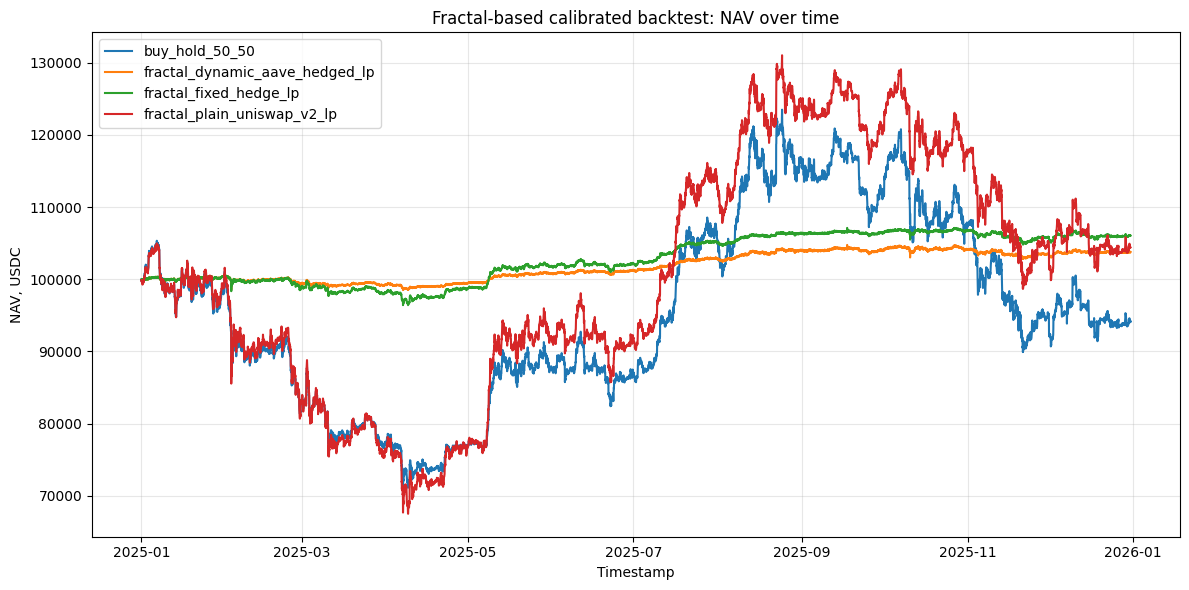

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

for strategy_name, group in nav.groupby("strategy_name"):
    group = group.sort_values("timestamp")
    ax.plot(group["timestamp"], group["nav"], label=strategy_name)

ax.set_title("Fractal-based calibrated backtest: NAV over time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("NAV, USDC")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

equity_path = CALIBRATED_FIGURES_DIR / "calibrated_equity_curve.png"
fig.savefig(equity_path, dpi=150)
print("Saved:", equity_path)
plt.show()

## 7. Drawdown

Drawdown-график важнее equity curve для защиты гипотезы.  
Он показывает, что hedge резко снижает downside risk plain LP.

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\fractal_calibrated\calibrated_drawdown.png


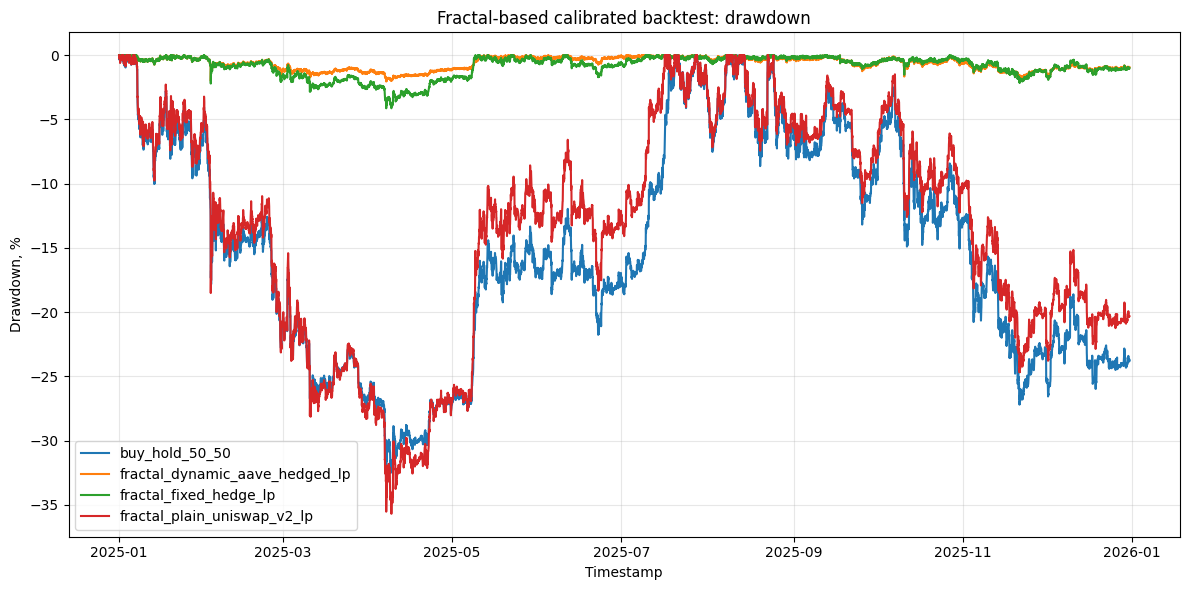

In [28]:
plot_df = nav.copy()

if "drawdown" not in plot_df.columns:
    plot_df["drawdown"] = (
        plot_df.groupby("strategy_name")["nav"]
        .transform(lambda x: x / x.cummax() - 1.0)
    )

fig, ax = plt.subplots(figsize=(12, 6))

for strategy_name, group in plot_df.groupby("strategy_name"):
    group = group.sort_values("timestamp")
    ax.plot(group["timestamp"], group["drawdown"] * 100, label=strategy_name)

ax.set_title("Fractal-based calibrated backtest: drawdown")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Drawdown, %")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

drawdown_path = CALIBRATED_FIGURES_DIR / "calibrated_drawdown.png"
fig.savefig(drawdown_path, dpi=150)
print("Saved:", drawdown_path)
plt.show()

## 8. Hedge diagnostics

Этот график нужен, чтобы показать, что dynamic hedge не является black box.  
Он сравнивает:

```text
LP ETH delta
target WETH debt
borrowed WETH
```

Для calibrated strategy target debt следует за LP delta, а borrowed debt меняется ступенчато при rebalance events.

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\figures\fractal_calibrated\calibrated_hedge_diagnostics.png


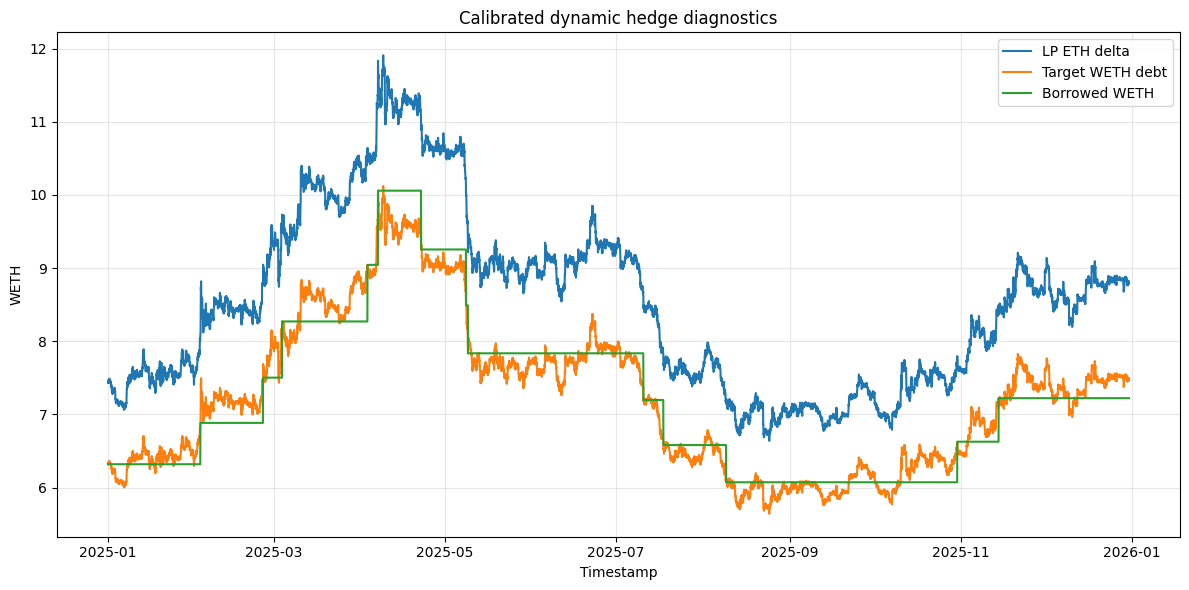

In [29]:
dyn = nav[nav["strategy_name"] == "fractal_dynamic_aave_hedged_lp"].copy()
dyn = dyn.sort_values("timestamp")

required = {"lp_eth_delta", "target_weth_debt", "borrowed_weth"}
missing = required - set(dyn.columns)

if missing:
    print("Missing hedge diagnostic columns:", missing)
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(dyn["timestamp"], dyn["lp_eth_delta"], label="LP ETH delta")
    ax.plot(dyn["timestamp"], dyn["target_weth_debt"], label="Target WETH debt")
    ax.plot(dyn["timestamp"], dyn["borrowed_weth"], label="Borrowed WETH")

    ax.set_title("Calibrated dynamic hedge diagnostics")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("WETH")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()

    hedge_path = CALIBRATED_FIGURES_DIR / "calibrated_hedge_diagnostics.png"
    fig.savefig(hedge_path, dpi=150)
    print("Saved:", hedge_path)
    plt.show()

## 9. Rebalance events

Calibrated strategy сделала 13 ребалансировок.  
Это больше, чем base dynamic version, где было 8 ребалансировок.

In [30]:
if rebalances.empty:
    print("No rebalances table found or no rebalance events.")
else:
    display_cols = [
        "timestamp", "strategy_name", "eth_price_usdc",
        "borrowed_weth", "target_weth_debt", "hedge_error",
        "turnover", "gas_cost", "slippage_cost",
        "health_factor", "regime",
    ]
    display_cols = [c for c in display_cols if c in rebalances.columns]
    display(rebalances[display_cols].head(20))

,timestamp,strategy_name,eth_price_usdc,borrowed_weth,target_weth_debt,hedge_error,turnover,gas_cost,slippage_cost,health_factor,regime
0,2025-02-02 22:00:00+00:00,fractal_dynamic_aave_hedged_lp,2874.70,6.884919,6.884919,0.0,1623.670624,15.0,1.623671,2.028899,downtrend
1,2025-02-25 06:00:00+00:00,fractal_dynamic_aave_hedged_lp,2480.41,7.502932,7.502932,0.0,1532.925601,15.0,1.532926,2.163469,downtrend
2,2025-03-04 01:00:00+00:00,fractal_dynamic_aave_hedged_lp,2054.89,8.270999,8.270999,0.0,1578.292237,15.0,1.578292,2.370889,downtrend
3,2025-04-03 12:00:00+00:00,fractal_dynamic_aave_hedged_lp,1759.40,9.043870,9.043870,0.0,1359.790099,15.0,1.359790,2.541603,downtrend
4,2025-04-07 06:00:00+00:00,fractal_dynamic_aave_hedged_lp,1429.59,10.057826,10.057826,0.0,1449.541539,15.0,1.449542,2.813878,downtrend
5,2025-04-22 15:00:00+00:00,fractal_dynamic_aave_hedged_lp,1703.95,9.254467,9.254467,0.0,1368.884644,15.0,1.368885,2.570434,high_vol_chop
6,2025-05-08 15:00:00+00:00,fractal_dynamic_aave_hedged_lp,2051.65,8.490850,8.490850,0.0,1566.675105,15.0,1.566675,2.331235,uptrend
7,2025-05-09 08:00:00+00:00,fractal_dynamic_aave_hedged_lp,2412.86,7.835739,7.835739,0.0,1580.689760,15.0,1.580690,2.148150,uptrend
8,2025-07-10 21:00:00+00:00,fractal_dynamic_aave_hedged_lp,2973.19,7.198146,7.198146,0.0,1895.684361,15.0,1.895684,1.911802,uptrend
9,2025-07-18 00:00:00+00:00,fractal_dynamic_aave_hedged_lp,3541.80,6.582083,6.582083,0.0,2181.972034,15.0,2.181972,1.756571,sideways


In [31]:
if not rebalances.empty:
    rb = rebalances.copy()
    rb["turnover"] = pd.to_numeric(rb.get("turnover", 0), errors="coerce").fillna(0.0)
    rb["gas_cost"] = pd.to_numeric(rb.get("gas_cost", 0), errors="coerce").fillna(0.0)
    rb["slippage_cost"] = pd.to_numeric(rb.get("slippage_cost", 0), errors="coerce").fillna(0.0)

    rb_summary = {
        "number_of_rebalances": len(rb),
        "total_turnover": rb["turnover"].sum(),
        "total_gas_cost": rb["gas_cost"].sum(),
        "total_slippage_cost": rb["slippage_cost"].sum(),
        "avg_turnover": rb["turnover"].mean(),
        "max_turnover": rb["turnover"].max(),
    }

    display(rb_summary)

{'number_of_rebalances': 13,
 'total_turnover': np.float64(22182.966295582974),
 'total_gas_cost': np.float64(195.0),
 'total_slippage_cost': np.float64(22.182966295582972),
 'avg_turnover': np.float64(1706.3820227371518),
 'max_turnover': np.float64(2181.9720343500426)}

## 10. PnL decomposition

Эта таблица помогает объяснить, откуда взялись результаты: LP fees, Aave costs, gas/slippage, turnover.

In [32]:
if pnl.empty:
    print("pnl_decomposition.csv not found.")
else:
    display(pnl)

,strategy_name,initial_nav,final_nav,net_pnl,total_lp_fees,total_aave_borrow_cost,total_aave_supply_yield,total_gas_cost,total_slippage_cost,total_turnover
0,buy_hold_50_50,100000.0,94137.823186,-5862.176814,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,fractal_dynamic_aave_hedged_lp,99925.0,103761.011221,3836.011221,5136.731021,901.124667,2160.804378,195.0,22.182966,22182.966296
2,fractal_fixed_hedge_lp,99925.0,106031.858214,6106.858214,5136.731021,819.268723,2160.804378,0.0,0.000000,0.000000
3,fractal_plain_uniswap_v2_lp,99850.0,104405.331848,4555.331848,10273.462042,0.000000,0.000000,0.0,0.000000,0.000000


## 11. Calibration top trials

Не нужно брать heatmap в презентацию.  
Лучше использовать top-10 trials table, чтобы показать устойчивость области параметров:

```text
hedge_ratio ≈ 0.85
rebalance_threshold ≈ 7%
```

In [33]:
trials_path = CALIBRATION_DIR / "calibration_trials.csv"

if trials_path.exists():
    trials = pd.read_csv(trials_path)
    cols = [
        "number", "value", "hedge_ratio", "rebalance_threshold",
        "target_final_nav", "target_sharpe", "target_max_drawdown",
        "target_turnover", "target_number_of_rebalances", "target_total_costs"
    ]
    cols = [c for c in cols if c in trials.columns]

    top_trials = trials.sort_values("value", ascending=False)[cols].head(10).copy()
    top_trials.to_csv(CALIBRATION_DIR / "top_10_trials_for_whitepaper.csv", index=False)
    print("Saved:", CALIBRATION_DIR / "top_10_trials_for_whitepaper.csv")
    display(top_trials)
else:
    print("Calibration trials file not found:", trials_path)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\calibration\top_10_trials_for_whitepaper.csv


,number,value,hedge_ratio,rebalance_threshold,target_final_nav,target_sharpe,target_max_drawdown,target_turnover,target_number_of_rebalances,target_total_costs
361,361,0.631080,0.849989,0.069659,103761.011221,0.632765,-0.020443,22182.966296,13.0,217.182966
624,624,0.631078,0.849982,0.069439,103761.014491,0.632763,-0.020444,22182.788257,13.0,217.182788
352,352,0.631071,0.849958,0.069487,103761.026208,0.632755,-0.020448,22182.150334,13.0,217.182150
245,245,0.631062,0.849927,0.069724,103761.040855,0.632746,-0.020453,22181.352941,13.0,217.181353
495,495,0.630973,0.849623,0.069518,103761.186956,0.632652,-0.020504,22173.398853,13.0,217.173399
242,242,0.630946,0.849531,0.069574,103761.230857,0.632624,-0.020520,22171.008786,13.0,217.171009
183,183,0.630777,0.848960,0.069554,103761.504445,0.632447,-0.020616,22156.114058,13.0,217.156114
440,440,0.630158,0.849997,0.069973,103753.852163,0.631857,-0.020513,22175.759655,13.0,217.175760
174,174,0.630121,0.849868,0.069735,103753.915061,0.631818,-0.020534,22172.395557,13.0,217.172396
80,80,0.630120,0.849864,0.069741,103753.916587,0.631817,-0.020535,22172.313920,13.0,217.172314


## 12. Base vs calibrated dynamic hedge

Если есть base results в `reports/results_tables/metrics.csv`, эта ячейка сравнит base dynamic и calibrated dynamic.  
Base version обычно:

```text
hedge_ratio = 0.75
rebalance_threshold = 10%
```

Calibrated version:

```text
hedge_ratio ≈ 0.85
rebalance_threshold ≈ 7%
```

In [34]:
base_metrics_path = BASE_RESULTS_DIR / "metrics.csv"

if base_metrics_path.exists():
    base_metrics = pd.read_csv(base_metrics_path)
    base_dyn = base_metrics[base_metrics["strategy_name"] == "fractal_dynamic_aave_hedged_lp"].copy()
    cal_dyn = metrics[metrics["strategy_name"] == "fractal_dynamic_aave_hedged_lp"].copy()

    if not base_dyn.empty and not cal_dyn.empty:
        rows = []
        for metric in [
            "final_nav", "net_pnl", "annualized_return", "annualized_volatility",
            "sharpe", "max_drawdown", "turnover", "number_of_rebalances", "total_costs"
        ]:
            rows.append({
                "metric": metric,
                "base_dynamic": float(base_dyn[metric].iloc[0]),
                "calibrated_dynamic": float(cal_dyn[metric].iloc[0]),
                "difference": float(cal_dyn[metric].iloc[0]) - float(base_dyn[metric].iloc[0]),
            })
        comparison = pd.DataFrame(rows)
        comparison.to_csv(CALIBRATED_RESULTS_DIR / "base_vs_calibrated_dynamic.csv", index=False)
        print("Saved:", CALIBRATED_RESULTS_DIR / "base_vs_calibrated_dynamic.csv")
        display(comparison)
    else:
        print("Could not find dynamic strategy in base or calibrated metrics.")
else:
    print("Base metrics not found:", base_metrics_path)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\base_vs_calibrated_dynamic.csv


,metric,base_dynamic,calibrated_dynamic,difference
0,final_nav,102780.794331,103761.011221,980.216889
1,net_pnl,2855.794331,3836.011221,980.216889
2,annualized_return,0.028659,0.038496,0.009837
3,annualized_volatility,0.069975,0.062808,-0.007168
4,sharpe,0.438763,0.632765,0.194002
5,max_drawdown,-0.041050,-0.020443,0.020607
6,turnover,19346.965963,22182.966296,2836.000333
7,number_of_rebalances,8.000000,13.000000,5.000000
8,total_costs,139.346966,217.182966,77.836000


## 13. Regime-level result summary

Этот блок показывает, как стратегии вели себя по рыночным режимам.  
Используй это для интерпретации, но не перегружай презентацию.

In [41]:
import numpy as np
import pandas as pd

def count_true(df: pd.DataFrame, col: str) -> int:
    if col not in df.columns:
        return 0

    s = df[col]

    if s.dtype == bool:
        return int(s.sum())

    s = s.astype("string").str.lower().str.strip()

    true_values = {"true", "1", "yes", "y"}
    return int(s.isin(true_values).sum())

def safe_sum(df: pd.DataFrame, col: str) -> float:
    if col not in df.columns:
        return 0.0
    return float(pd.to_numeric(df[col], errors="coerce").fillna(0.0).sum())


def safe_mean(df: pd.DataFrame, col: str) -> float:
    if col not in df.columns:
        return np.nan
    s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return float(s.mean()) if len(s) else np.nan


def safe_last(df: pd.DataFrame, col: str) -> float:
    if col not in df.columns:
        return np.nan
    s = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return float(s.iloc[-1]) if len(s) else np.nan


def local_max_drawdown(nav_series: pd.Series) -> float:
    nav_series = pd.to_numeric(nav_series, errors="coerce").dropna()
    if len(nav_series) < 2:
        return np.nan
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1.0
    return float(drawdown.min())


def annualized_return_from_period_returns(returns: pd.Series, periods_per_year: int = 8760) -> float:
    returns = pd.to_numeric(returns, errors="coerce").dropna()
    if len(returns) == 0:
        return np.nan

    total_return = float((1.0 + returns).prod() - 1.0)
    periods = len(returns)

    if periods <= 0 or total_return <= -1.0:
        return np.nan

    return float((1.0 + total_return) ** (periods_per_year / periods) - 1.0)


def annualized_volatility(returns: pd.Series, periods_per_year: int = 8760) -> float:
    returns = pd.to_numeric(returns, errors="coerce").dropna()
    if len(returns) < 2:
        return np.nan
    return float(returns.std(ddof=1) * np.sqrt(periods_per_year))


def sharpe_no_rf(returns: pd.Series, periods_per_year: int = 8760) -> float:
    ann_ret = annualized_return_from_period_returns(returns, periods_per_year)
    ann_vol = annualized_volatility(returns, periods_per_year)

    if pd.isna(ann_ret) or pd.isna(ann_vol) or ann_vol == 0:
        return np.nan

    return float(ann_ret / ann_vol)


nav_regime = nav.copy()
nav_regime["timestamp"] = pd.to_datetime(nav_regime["timestamp"], utc=True)
nav_regime = nav_regime.sort_values(["strategy_name", "timestamp"]).reset_index(drop=True)

nav_regime["period_return"] = (
    nav_regime.groupby("strategy_name")["nav"]
    .pct_change()
    .fillna(0.0)
)

# ---------------------------------------------------------------------
# 1. Aggregate regime-level metrics
# ---------------------------------------------------------------------

regime_summary = []

for strategy_name, group in nav_regime.groupby("strategy_name"):
    group = group.sort_values("timestamp").copy()

    for regime, rg in group.groupby("regime"):
        rg = rg.sort_values("timestamp").copy()

        if len(rg) < 2:
            continue

        returns = rg["period_return"]

        start_nav = float(rg["nav"].iloc[0])
        end_nav = float(rg["nav"].iloc[-1])
        simple_return_start_end = end_nav / start_nav - 1.0 if start_nav > 0 else np.nan

        compounded_return_inside_regime = float((1.0 + returns).prod() - 1.0)

        row = {
            "strategy_name": strategy_name,
            "regime": regime,
            "observations": len(rg),
            "share_of_strategy_observations": len(rg) / len(group),

            "start_timestamp": rg["timestamp"].iloc[0],
            "end_timestamp": rg["timestamp"].iloc[-1],

            "start_nav": start_nav,
            "end_nav": end_nav,

            # Careful: this spans first to last occurrence and may cross other regimes.
            "simple_return_start_to_end": simple_return_start_end,

            # Better for non-contiguous regimes: compounds only periods assigned to this regime.
            "compounded_return_inside_regime": compounded_return_inside_regime,

            "annualized_return_inside_regime": annualized_return_from_period_returns(returns),
            "annualized_volatility_inside_regime": annualized_volatility(returns),
            "sharpe_inside_regime": sharpe_no_rf(returns),

            # Local drawdown computed only inside regime subset.
            "local_max_drawdown_inside_regime": local_max_drawdown(rg["nav"]),

            # Existing global drawdown values observed during this regime.
            "min_global_drawdown_seen_in_regime": (
                float(rg["drawdown"].min()) if "drawdown" in rg.columns else np.nan
            ),

            "mean_nav": float(rg["nav"].mean()),
            "median_nav": float(rg["nav"].median()),
            "min_nav": float(rg["nav"].min()),
            "max_nav": float(rg["nav"].max()),

            "total_lp_fees": safe_sum(rg, "lp_fees"),
            "total_aave_borrow_cost": safe_sum(rg, "aave_borrow_cost"),
            "total_aave_supply_yield": safe_sum(rg, "aave_supply_yield"),
            "total_gas_cost": safe_sum(rg, "gas_cost"),
            "total_slippage_cost": safe_sum(rg, "slippage_cost"),
            "total_costs": safe_sum(rg, "gas_cost") + safe_sum(rg, "slippage_cost"),
            "total_turnover": safe_sum(rg, "turnover"),

            "number_of_rebalances": count_true(rg, "rebalance_event"),
            "circuit_breaker_events": count_true(rg, "circuit_breaker_active"),

            "average_health_factor": safe_mean(rg, "health_factor"),
            "min_health_factor": (
                float(
                    pd.to_numeric(rg.get("health_factor"), errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                    .min()
                )
                if "health_factor" in rg.columns
                and len(
                    pd.to_numeric(rg["health_factor"], errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )
                else np.nan
            ),

            "average_idle_ratio": safe_mean(rg, "idle_ratio"),
            "max_idle_ratio": (
                float(pd.to_numeric(rg["idle_ratio"], errors="coerce").max())
                if "idle_ratio" in rg.columns
                else np.nan
            ),

            "average_hedge_error": safe_mean(rg, "hedge_error"),
            "max_hedge_error": (
                float(pd.to_numeric(rg["hedge_error"], errors="coerce").max())
                if "hedge_error" in rg.columns
                else np.nan
            ),

            "average_borrowed_weth": safe_mean(rg, "borrowed_weth"),
            "final_borrowed_weth": safe_last(rg, "borrowed_weth"),
            "average_lp_eth_delta": safe_mean(rg, "lp_eth_delta"),
            "final_lp_eth_delta": safe_last(rg, "lp_eth_delta"),
        }

        regime_summary.append(row)

regime_summary = pd.DataFrame(regime_summary)

regime_summary_path = CALIBRATED_RESULTS_DIR / "regime_level_results.csv"
regime_summary.to_csv(regime_summary_path, index=False)

print("Saved:", regime_summary_path)

display(
    regime_summary.sort_values(
        ["strategy_name", "regime"]
    ).reset_index(drop=True)
)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\regime_level_results.csv


,strategy_name,regime,observations,share_of_strategy_observations,start_timestamp,end_timestamp,start_nav,end_nav,simple_return_start_to_end,compounded_return_inside_regime,annualized_return_inside_regime,annualized_volatility_inside_regime,sharpe_inside_regime,local_max_drawdown_inside_regime,min_global_drawdown_seen_in_regime,mean_nav,median_nav,min_nav,max_nav,total_lp_fees,total_aave_borrow_cost,total_aave_supply_yield,total_gas_cost,total_slippage_cost,total_costs,total_turnover,number_of_rebalances,circuit_breaker_events,average_health_factor,min_health_factor,average_idle_ratio,max_idle_ratio,average_hedge_error,max_hedge_error,average_borrowed_weth,final_borrowed_weth,average_lp_eth_delta,final_lp_eth_delta
0,buy_hold_50_50,downtrend,669,0.076571,2025-01-07 15:00:00+00:00,2025-12-16 13:00:00+00:00,101548.909806,93345.645181,-0.080781,-0.571520,-0.999985,0.543304,-1.840561,-0.299740,-0.324832,91854.185467,90800.220422,71110.598117,118327.922078,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,buy_hold_50_50,high_vol_chop,1573,0.180039,2025-01-09 15:00:00+00:00,2025-12-19 16:00:00+00:00,99440.009532,94172.673657,-0.052970,0.114211,0.826256,0.415686,1.987694,-0.287203,-0.317421,94295.204663,93300.369355,71891.159299,120740.646968,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,buy_hold_50_50,sideways,5758,0.659036,2025-01-02 00:00:00+00:00,2025-12-31 00:00:00+00:00,100387.525319,94137.823186,-0.062256,-0.089964,-0.133610,0.247312,-0.540248,-0.306505,-0.306505,96531.614131,94893.140117,73040.926963,123485.344930,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,buy_hold_50_50,uptrend,713,0.081607,2025-01-03 22:00:00+00:00,2025-12-20 02:00:00+00:00,103838.764447,94406.052663,-0.090840,1.168032,13455.761454,0.433293,31054.622740,-0.294076,-0.304023,95373.524513,94237.608722,73302.305493,122252.174431,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,buy_hold_50_50,warmup,24,0.002747,2025-01-01 00:00:00+00:00,2025-01-01 23:00:00+00:00,100000.000000,99940.575480,-0.000594,-0.000594,-0.195041,0.120571,-1.617651,-0.005487,-0.005487,99772.851384,99741.898010,99451.328488,100067.466937,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
5,fractal_dynamic_aave_hedged_lp,downtrend,669,0.076571,2025-01-07 15:00:00+00:00,2025-12-16 13:00:00+00:00,100138.461148,103659.972675,0.035166,-0.071654,-0.622265,0.101188,-6.149575,-0.018184,-0.020443,101205.207863,100588.006255,98496.272233,104479.442555,1181.012178,63.637284,164.780198,105.0,11.443371,116.443371,11443.370991,7,3,2.118605,1.476366,0.219441,0.289027,0.030005,0.069406,7.300828,7.222924,8.834734,8.892693
6,fractal_dynamic_aave_hedged_lp,high_vol_chop,1573,0.180039,2025-01-09 15:00:00+00:00,2025-12-19 16:00:00+00:00,100035.878017,103707.601133,0.036704,0.024282,0.142949,0.063447,2.253055,-0.019271,-0.019271,101497.433516,100669.718951,98614.077812,104552.949693,1087.400268,157.785796,387.023838,15.0,1.368885,16.368885,1368.884644,1,45,2.003580,1.425657,0.216336,0.288655,0.024187,0.067339,7.247720,7.222924,8.583356,8.800192
7,fractal_dynamic_aave_hedged_lp,sideways,5758,0.659036,2025-01-02 00:00:00+00:00,2025-12-31 00:00:00+00:00,99971.997536,103761.011221,0.037901,0.025369,0.038850,0.056289,0.690197,-0.017388,-0.017388,101897.081336,101729.378845,98836.624072,104745.348856,2263.622727,602.073698,1426.157227,15.0,2.181972,17.181972,2181.972034,1,258,1.948098,1.372593,0.211663,0.287939,0.022811,0.068897,7.193313,7.222924,8.473616,8.807336
8,fractal_dynamic_aave_hedged_lp,uptrend,713,0.081607,2025-01-03 22:00:00+00:00,2025-12-20 02:00:00+00:00,100175.103669,103688.407472,0.035072,0.064673,1.159655,0.063178,18.355416,-0.017277,-0.018330,101670.507629,101354.435431,98708.70

In [42]:
# ---------------------------------------------------------------------
# 2. Contiguous regime-segment metrics
# ---------------------------------------------------------------------

segment_rows = []

for strategy_name, group in nav_regime.groupby("strategy_name"):
    group = group.sort_values("timestamp").copy()

    group["regime_shift"] = group["regime"].ne(group["regime"].shift())
    group["regime_segment_id"] = group["regime_shift"].cumsum()

    for segment_id, seg in group.groupby("regime_segment_id"):
        seg = seg.sort_values("timestamp").copy()

        if len(seg) < 2:
            continue

        regime = seg["regime"].iloc[0]
        returns = seg["period_return"]

        start_nav = float(seg["nav"].iloc[0])
        end_nav = float(seg["nav"].iloc[-1])

        segment_rows.append({
            "strategy_name": strategy_name,
            "regime_segment_id": int(segment_id),
            "regime": regime,

            "start_timestamp": seg["timestamp"].iloc[0],
            "end_timestamp": seg["timestamp"].iloc[-1],
            "observations": len(seg),

            "start_nav": start_nav,
            "end_nav": end_nav,
            "segment_return": end_nav / start_nav - 1.0 if start_nav > 0 else np.nan,

            "segment_compounded_return": float((1.0 + returns).prod() - 1.0),
            "segment_annualized_return": annualized_return_from_period_returns(returns),
            "segment_annualized_volatility": annualized_volatility(returns),
            "segment_sharpe": sharpe_no_rf(returns),

            "segment_local_max_drawdown": local_max_drawdown(seg["nav"]),

            "total_lp_fees": safe_sum(seg, "lp_fees"),
            "total_aave_borrow_cost": safe_sum(seg, "aave_borrow_cost"),
            "total_aave_supply_yield": safe_sum(seg, "aave_supply_yield"),
            "total_gas_cost": safe_sum(seg, "gas_cost"),
            "total_slippage_cost": safe_sum(seg, "slippage_cost"),
            "total_turnover": safe_sum(seg, "turnover"),

            "number_of_rebalances": count_true(seg, "rebalance_event"),
            "circuit_breaker_events": count_true(seg, "circuit_breaker_active"),

            "average_health_factor": safe_mean(seg, "health_factor"),
            "min_health_factor": (
                float(
                    pd.to_numeric(seg.get("health_factor"), errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                    .min()
                )
                if "health_factor" in seg.columns
                and len(
                    pd.to_numeric(seg["health_factor"], errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )
                else np.nan
            ),

            "average_idle_ratio": safe_mean(seg, "idle_ratio"),
            "average_hedge_error": safe_mean(seg, "hedge_error"),
            "max_hedge_error": (
                float(pd.to_numeric(seg["hedge_error"], errors="coerce").max())
                if "hedge_error" in seg.columns
                else np.nan
            ),
        })

regime_segments = pd.DataFrame(segment_rows)

regime_segments_path = CALIBRATED_RESULTS_DIR / "regime_segment_results.csv"
regime_segments.to_csv(regime_segments_path, index=False)

print("Saved:", regime_segments_path)

display(
    regime_segments.sort_values(
        ["strategy_name", "start_timestamp"]
    ).reset_index(drop=True).head(30)
)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\regime_segment_results.csv


,strategy_name,regime_segment_id,regime,start_timestamp,end_timestamp,observations,start_nav,end_nav,segment_return,segment_compounded_return,segment_annualized_return,segment_annualized_volatility,segment_sharpe,segment_local_max_drawdown,total_lp_fees,total_aave_borrow_cost,total_aave_supply_yield,total_gas_cost,total_slippage_cost,total_turnover,number_of_rebalances,circuit_breaker_events,average_health_factor,min_health_factor,average_idle_ratio,average_hedge_error,max_hedge_error
0,buy_hold_50_50,1,warmup,2025-01-01 00:00:00+00:00,2025-01-01 23:00:00+00:00,24,100000.000000,99940.575480,-0.000594,-0.000594,-1.950410e-01,0.120571,-1.617651e+00,-0.005487,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
1,buy_hold_50_50,2,sideways,2025-01-02 00:00:00+00:00,2025-01-03 21:00:00+00:00,46,100387.525319,103806.594781,0.034059,0.038683,1.376068e+03,0.231451,5.945398e+03,-0.009532,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
2,buy_hold_50_50,4,sideways,2025-01-03 23:00:00+00:00,2025-01-07 14:00:00+00:00,88,103731.234362,103153.222924,-0.005572,-0.006602,-4.828261e-01,0.189514,-2.547710e+00,-0.020600,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
3,buy_hold_50_50,5,downtrend,2025-01-07 15:00:00+00:00,2025-01-08 14:00:00+00:00,24,101548.909806,100170.380079,-0.013575,-0.028917,-9.999777e-01,0.422906,-2.364541e+00,-0.022408,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
4,buy_hold_50_50,6,sideways,2025-01-08 15:00:00+00:00,2025-01-08 16:00:00+00:00,2,99833.790063,99335.011319,-0.004996,-0.008339,-1.000000e+00,0.108268,-9.236381e+00,-0.004996,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
5,buy_hold_50_50,8,sideways,2025-01-08 18:00:00+00:00,2025-01-09 14:00:00+00:00,21,98887.614679,98397.771953,-0.004954,-0.001961,-5.590087e-01,0.327334,-1.707762e+00,-0.018858,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
6,buy_hold_50_50,9,high_vol_chop,2025-01-09 15:00:00+00:00,2025-01-10 14:00:00+00:00,24,99440.009532,98499.046825,-0.009463,0.001029,4.556888e-01,0.400755,1.137077e+00,-0.018687,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
7,buy_hold_50_50,10,sideways,2025-01-10 15:00:00+00:00,2025-01-13 10:00:00+00:00,68,98322.560467,96402.954843,-0.019524,-0.021280,-9.374004e-01,0.251445,-3.728059e+00,-0.029802,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
8,buy_hold_50_50,11,downtrend,2025-01-13 11:00:00+00:00,2025-01-13 20:00:00+00:00,10,95478.523770,96029.280353,0.005768,-0.003876,-9.666976e-01,0.524357,-1.843586e+00,-0.007993,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN
9,buy_hold_50_50,12,high_vol_chop,2025-01-13 21:00:00+00:00,2025-01-13 23:00:00+00:00,3,96366.168235,96717.353747,0.003644,0.007165,1.132752e+09,0.123591,9.165296e+09,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0,NaN,NaN,0.0,NaN,NaN


In [43]:
# ---------------------------------------------------------------------
# 3. Compact regime table for presentation / whitepaper
# ---------------------------------------------------------------------

presentation_cols = [
    "strategy_name",
    "regime",
    "observations",
    "compounded_return_inside_regime",
    "annualized_volatility_inside_regime",
    "sharpe_inside_regime",
    "local_max_drawdown_inside_regime",
    "total_lp_fees",
    "total_turnover",
    "number_of_rebalances",
    "total_costs",
    "average_health_factor",
    "average_idle_ratio",
]

compact_regime_summary = regime_summary[presentation_cols].copy()

percent_cols = [
    "compounded_return_inside_regime",
    "annualized_volatility_inside_regime",
    "local_max_drawdown_inside_regime",
    "average_idle_ratio",
]

for col in percent_cols:
    compact_regime_summary[col] = compact_regime_summary[col] * 100

compact_regime_summary = compact_regime_summary.sort_values(
    ["regime", "strategy_name"]
).reset_index(drop=True)

compact_path = CALIBRATED_RESULTS_DIR / "regime_level_results_compact.csv"
compact_regime_summary.to_csv(compact_path, index=False)

print("Saved:", compact_path)

display(compact_regime_summary)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\regime_level_results_compact.csv


,strategy_name,regime,observations,compounded_return_inside_regime,annualized_volatility_inside_regime,sharpe_inside_regime,local_max_drawdown_inside_regime,total_lp_fees,total_turnover,number_of_rebalances,total_costs,average_health_factor,average_idle_ratio
0,buy_hold_50_50,downtrend,669,-57.152027,54.330426,-1.840561,-29.974041,0.000000,0.000000,0,0.000000,NaN,0.000000
1,fractal_dynamic_aave_hedged_lp,downtrend,669,-7.165400,10.118825,-6.149575,-1.818442,1181.012178,11443.370991,7,116.443371,2.118605,21.944148
2,fractal_fixed_hedge_lp,downtrend,669,-9.418424,11.941162,-6.081277,-3.907996,1181.012178,0.000000,0,0.000000,2.495709,20.505630
3,fractal_plain_uniswap_v2_lp,downtrend,669,-59.318065,65.251413,-1.532522,-33.565255,2362.024356,0.000000,0,0.000000,NaN,0.000000
4,buy_hold_50_50,high_vol_chop,1573,11.421147,41.568567,1.987694,-28.720319,0.000000,0.000000,0,0.000000,NaN,0.000000
5,fractal_dynamic_aave_hedged_lp,high_vol_chop,1573,2.428221,6.344656,2.253055,-1.927115,1087.400268,1368.884644,1,16.368885,2.003580,21.633628
6,fractal_fixed_hedge_lp,high_vol_chop,1573,2.909798,7.434212,2.329739,-3.805003,1087.400268,0.000000,0,0.000000,2.337772,20.379959
7,fractal_plain_uniswap_v2_lp,high_vol_chop,1573,14.062809,44.453753,2.431330,-32.090174,2174.800537,0.000000,0,0.000000,NaN,0.000000
8,buy_hold_50_50,sideways,5758,-8.996351,24.731178,-0.540248,-30.650471,0.000000,0.000000,0,0.000000,NaN,0.000000
9,fractal_dynamic_aave_hedged_lp,sideways,5758,2.536934,5.628852,0.690197,-1.738797,2263.622727,2181.972034,1,17.181972,1.948098,21.166267


## 14. Export chart list for presentation

Рекомендуемые графики для презентации:

```text
1. calibrated_equity_curve.png
2. calibrated_drawdown.png
3. calibrated_hedge_diagnostics.png
4. ETH price / regime plot from EDA notebook
5. Volume / fees plot from EDA notebook
```

Heatmap calibration лучше не брать.

In [36]:
generated_files = sorted(CALIBRATED_FIGURES_DIR.glob("*.png"))

for path in generated_files:
    print(path.relative_to(PROJECT_ROOT))

reports\figures\fractal_calibrated\backtest_drawdown.png
reports\figures\fractal_calibrated\backtest_equity_curve.png
reports\figures\fractal_calibrated\backtest_hedge_diagnostics.png
reports\figures\fractal_calibrated\calibrated_drawdown.png
reports\figures\fractal_calibrated\calibrated_equity_curve.png
reports\figures\fractal_calibrated\calibrated_hedge_diagnostics.png


## 15. Final interpretation for whitepaper / presentation

Короткая итоговая формулировка:

```text
Гипотеза подтверждается частично. Aave hedge не является способом гарантированно максимизировать доходность LP, но существенно улучшает риск-профиль plain LP. Calibrated dynamic hedge снижает max drawdown с -35.7% у plain LP до -2.04%, а annualized volatility — с 36.17% до 6.28%. При этом fixed hedge остаётся сильным baseline и показывает более высокий final NAV и Sharpe на выбранном историческом периоде.
```

Главный takeaway:

```text
Dynamic hedge = downside protection, not absolute return maximization.
```

In [37]:
final_summary = {
    "calibrated_params": PARAMS,
    "metrics": metrics.to_dict(orient="records"),
    "figure_paths": [str(p.relative_to(PROJECT_ROOT)) for p in sorted(CALIBRATED_FIGURES_DIR.glob("*.png"))],
}

summary_path = CALIBRATED_RESULTS_DIR / "notebook_summary.json"
summary_path.write_text(json.dumps(final_summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("Saved:", summary_path)

Saved: d:\VS\defi-lp-aave-hedge-strategy\reports\results_tables\fractal_calibrated\notebook_summary.json
